In [1]:
import numpy as np
import pandas as pd
import sklearn
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report,accuracy_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from pylab import rcParams
rcParams['figure.figsize'] = 14, 8
RANDOM_SEED = 42
LABELS = ["Normal", "Fraud"]

In [4]:
from google.colab import files
upload = files.upload()

Saving creditcard.csv to creditcard.csv


In [5]:
data = pd.read_csv('creditcard.csv',sep=',')
data.head()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  690 non-null    int64  
 1   A1          690 non-null    int64  
 2   A2          690 non-null    float64
 3   A3          690 non-null    float64
 4   A4          690 non-null    int64  
 5   A5          690 non-null    int64  
 6   A6          690 non-null    int64  
 7   A7          690 non-null    float64
 8   A8          690 non-null    int64  
 9   A9          690 non-null    int64  
 10  A10         690 non-null    int64  
 11  A11         690 non-null    int64  
 12  A12         690 non-null    int64  
 13  A13         690 non-null    int64  
 14  A14         690 non-null    int64  
 15  Class       690 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 86.4 KB


In [7]:
data.isnull().values.any()

np.False_

/tmp/ipykernel_1680/351607490.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(data['Class'], sort = True)


Text(0, 0.5, 'Frequency')

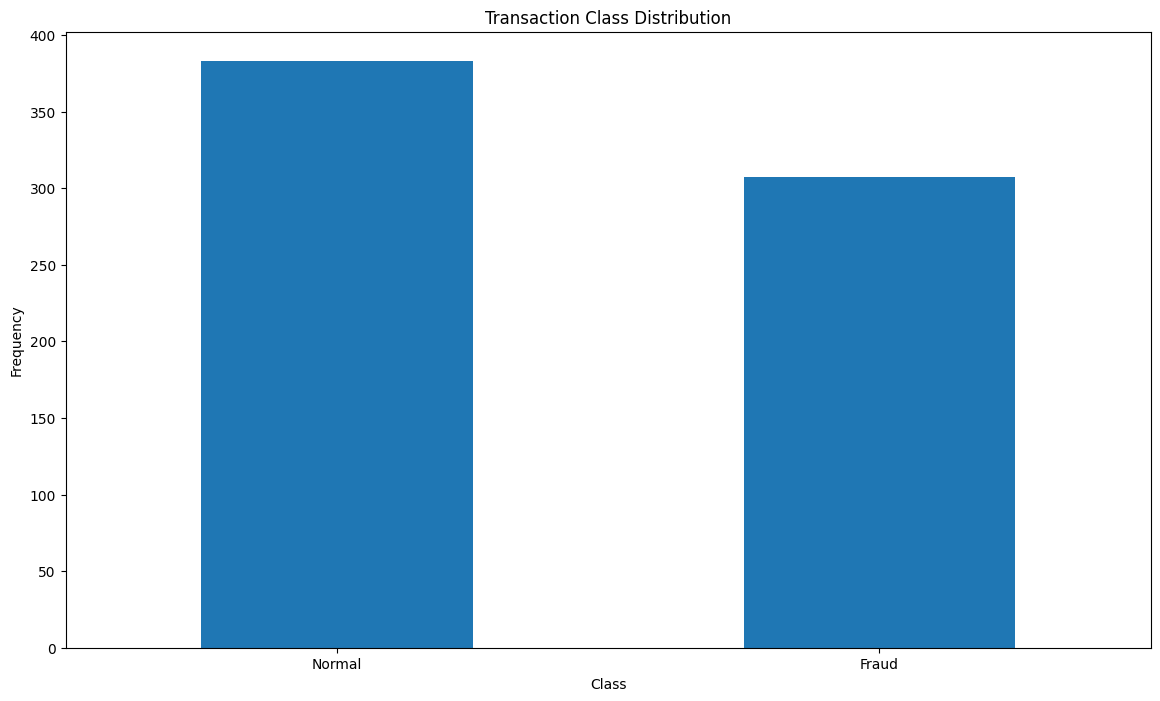

In [8]:
count_classes = pd.value_counts(data['Class'], sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.title("Transaction Class Distribution")
plt.xticks(range(2), LABELS)
plt.xlabel("Class")
plt.ylabel("Frequency")

In [9]:
fraud = data[data['Class']==1]
normal = data[data['Class']==0]
print(fraud.shape,normal.shape)

(307, 16) (383, 16)


In [11]:
fraud.columns

Index(['CustomerID', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9',
       'A10', 'A11', 'A12', 'A13', 'A14', 'Class'],
      dtype='object')

In [12]:
fraud["A1"].describe()

,A1
count,307.000000
mean,0.671010
std,0.470614
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [13]:
normal.A1.describe()

,A1
count,383.000000
mean,0.684073
std,0.465492
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


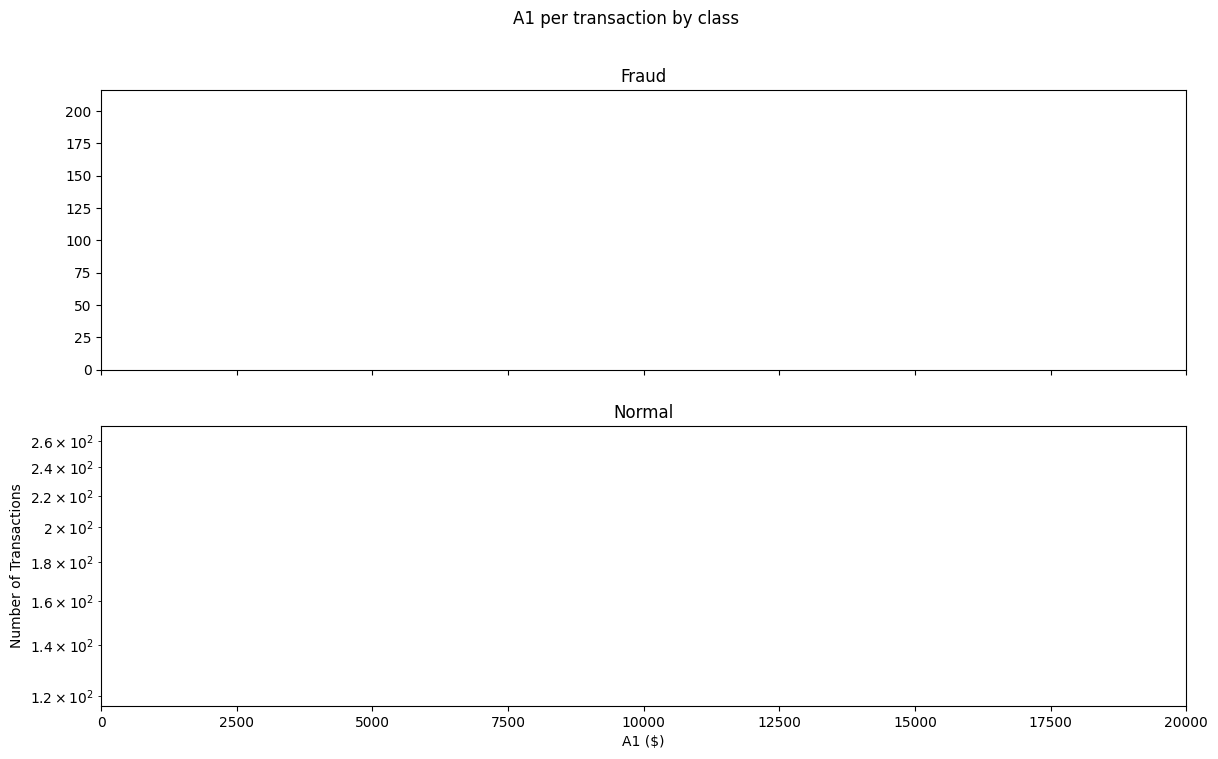

In [21]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('A1 per transaction by class')
bins = 50
ax1.hist(fraud.A1, bins = bins)
ax1.set_title('Fraud')
ax2.hist(normal.A1, bins = bins)
ax2.set_title('Normal')
plt.xlabel('A1 ($)')
plt.ylabel('Number of Transactions')
plt.xlim((0, 20000))
plt.yscale('log')
plt.show();

In [17]:
print(fraud_data["Class"].value_counts())

NameError: name 'fraud_data' is not defined

In [18]:
print(fraud.shape)
print(fraud.columns)
print(fraud["Class"].value_counts())

(307, 16)
Index(['CustomerID', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9',
       'A10', 'A11', 'A12', 'A13', 'A14', 'Class'],
      dtype='object')
Class
1    307
Name: count, dtype: int64


In [19]:
print(normal.shape)
print(normal["Class"].value_counts())

(383, 16)
Class
0    383
Name: count, dtype: int64


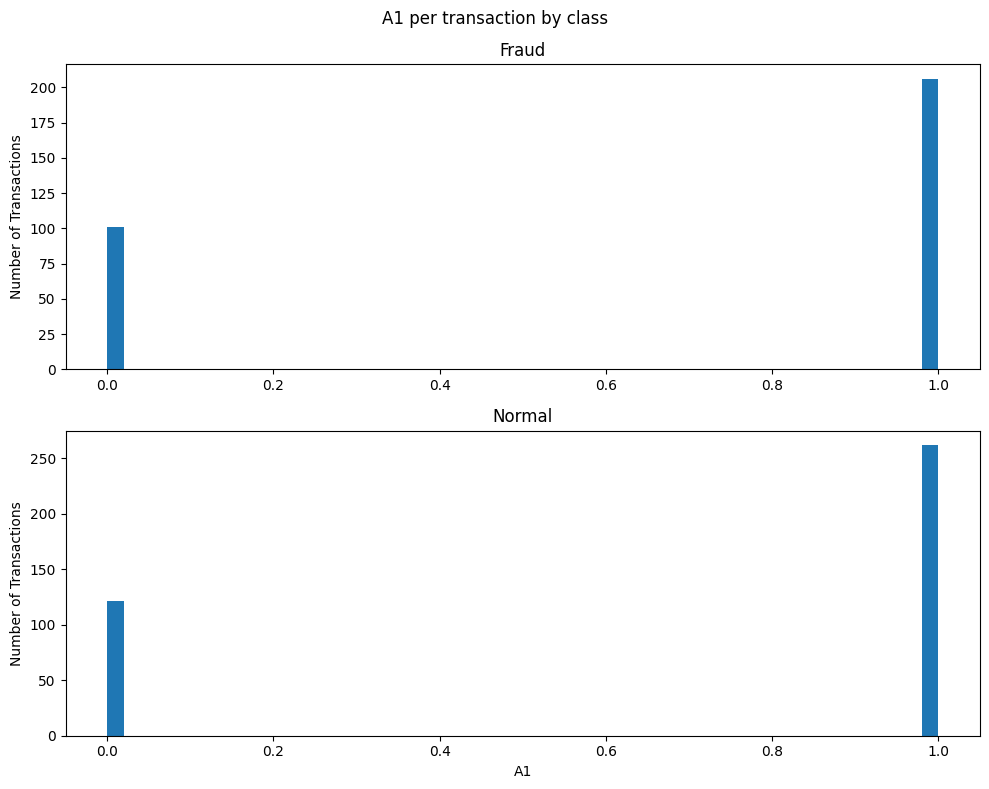

In [22]:
import matplotlib.pyplot as plt
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
f.suptitle('A1 per transaction by class')
bins = 50
# Fraud
ax1.hist(fraud["A1"], bins=bins)
ax1.set_title('Fraud')
ax1.set_ylabel('Number of Transactions')
# Normal
ax2.hist(normal["A1"], bins=bins)
ax2.set_title('Normal')
ax2.set_xlabel('A1')
ax2.set_ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

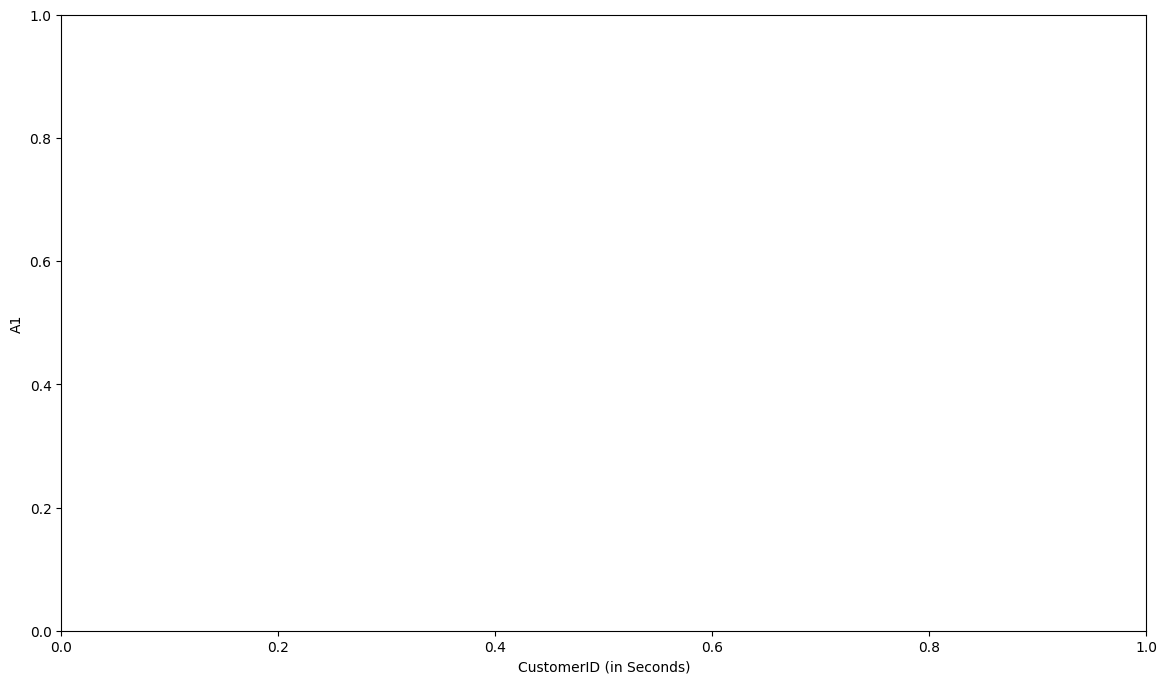

In [27]:
f.suptitle('CustomerID vs A1 by class')
ax1.scatter(fraud.CustomerID, fraud.A1)
ax1.set_title('Fraud')
ax2.scatter(normal.CustomerID, normal.A1)
ax2.set_title('Normal')
plt.xlabel('CustomerID (in Seconds)')
plt.ylabel('A1')
plt.show()

In [28]:
data.shape

(690, 16)

In [30]:
Fraud = data[data['Class']==1]
Valid = data[data['Class']==0]
outlier_fraction = len(Fraud)/float(len(Valid))
print(outlier_fraction)
print("Fraud Cases : {}".format(len(Fraud)))
print("Valid Cases : {}".format(len(Valid)))

0.8015665796344648
Fraud Cases : 307
Valid Cases : 383


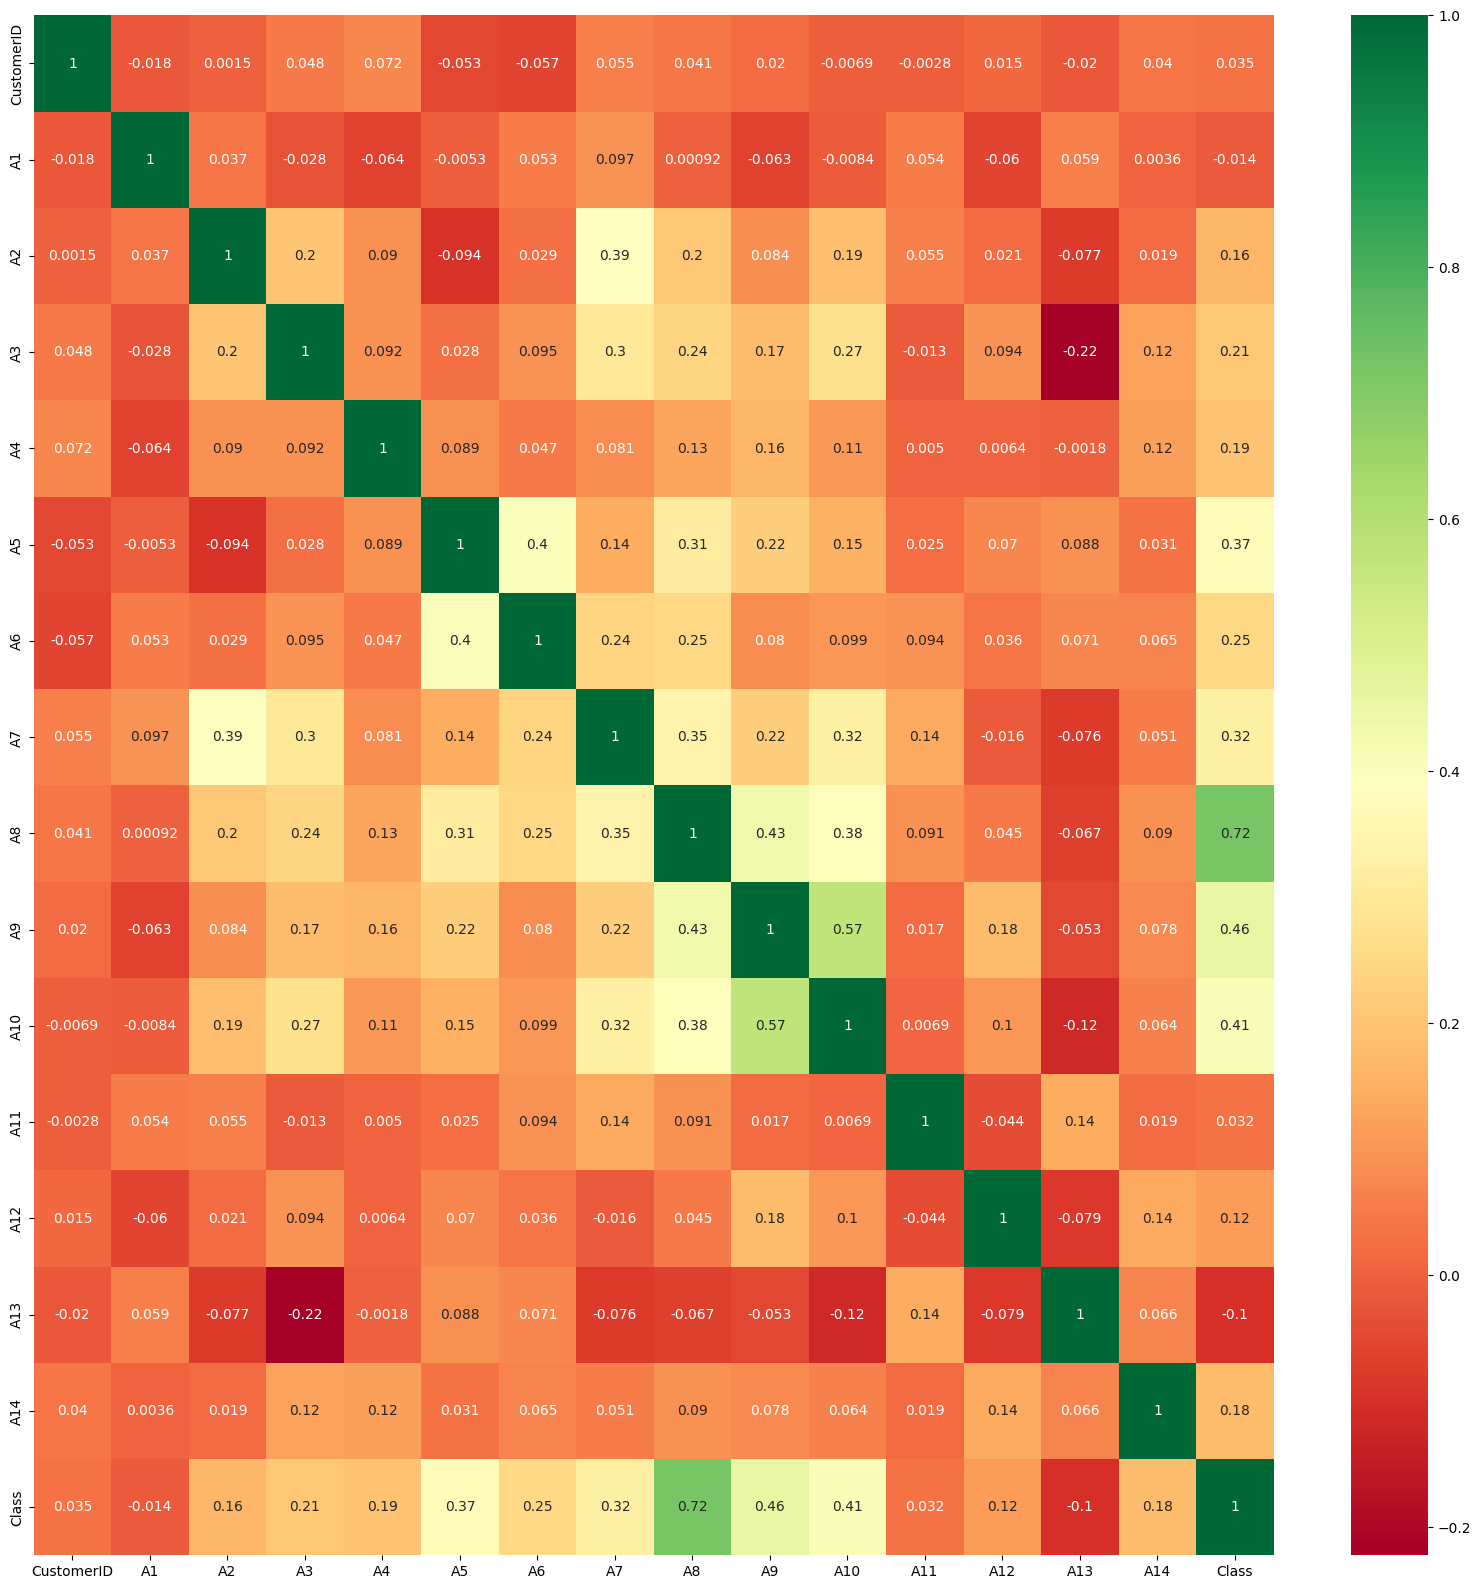

In [32]:
## Correlation
import seaborn as sns
#get correlations of each features in dataset
corrmat = data.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
#plot heat map
g=sns.heatmap(data[top_corr_features].corr(),annot=True,cmap="RdYlGn")

In [34]:
#Create independent and Dependent Features
columns = data.columns.tolist()
# Filter the columns to remove data we do not want
columns = [c for c in columns if c not in ["Class"]] # Store the variable we are predicting
target = "Class"
# Define a random state
state = np.random.RandomState(42)
X = data[columns]
Y = data[target]
X_outliers = state.uniform(low=0, high=1, size=(X.shape[0],X.shape[1]))
# Print the shapes of X & Y
print(X.shape)
print(Y.shape)

(690, 15)
(690,)


In [37]:
classifiers = {"Isolation Forest":IsolationForest(n_estimators=100, max_samples=len(X),
                                contamination=outlier_fraction,random_state=state, verbose=0), "Local Outlier Factor":LocalOutlierFactor(n_neighbors=20, algorithm='auto', leaf_size=30, metric='minkowski', p=2, metric_params=None, contamination=outlier_fraction)
                                }
type(classifiers)
dict n_outliers = len(Fraud)
for i, (clf_name,clf) in enumerate(classifiers.items()):
#Fit the data and tag outliers
if clf_name == "Local Outlier Factor":
  y_pred = clf.fit_predict(X)
  scores_prediction = clf.negative_outlier_factorelse:
  clf.fit(X)
  scores_prediction = clf.decision_function(X)
  y_pred = clf.predict(X)
  #Reshape the prediction values to 0 for Valid transactions , 1 for Fraud transactions
  y_pred[y_pred == 1] = 0
  y_pred[y_pred == -1] = 1
  n_errors = (y_pred != Y).sum()
  # Run Classification Metrics
  print("{}: {}".format(clf_name,n_errors))
  print("Accuracy Score :")
  print(accuracy_score(Y,y_pred))
  print("Classification Report :")
  print(classification_report(Y,y_pred))

SyntaxError: invalid syntax (2316506352.py, line 5)

In [38]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import accuracy_score, classification_report
state = 1

In [45]:
classifiers = {
    "Isolation Forest": IsolationForest(
        n_estimators=100,
        max_samples=len(X),
        contamination=outlier_fraction,
        random_state=state,
        verbose=0
    ),

    "Local Outlier Factor": LocalOutlierFactor(
        n_neighbors=20,
        algorithm='auto',
        leaf_size=30,
        metric='minkowski',
        p=2,
        metric_params=None,
        contamination=outlier_fraction
    )
}

type(classifiers)

n_outliers = len(Fraud)

for i, (clf_name, clf) in enumerate(classifiers.items()):

    # Fit the data and tag outliers
    if clf_name == "Local Outlier Factor":
        y_pred = clf.fit_predict(X)
        scores_prediction = clf.negative_outlier_factor_

    else:
        clf.fit(X)
        scores_prediction = clf.decision_function(X)
        y_pred = clf.predict(X)

    # Reshape the prediction values
    # 0 = Valid transactions
    # 1 = Fraud transactions
    y_pred[y_pred == 1] = 0
    y_pred[y_pred == -1] = 1

    n_errors = (y_pred != Y).sum()

    # Run Classification Metrics
    print("{}: {}".format(clf_name, n_errors))

    print("Accuracy Score:")
    print(accuracy_score(Y, y_pred))

    print("Classification Report:")
    print(classification_report(Y, y_pred))

InvalidParameterError: The 'contamination' parameter of IsolationForest must be a str among {'auto'} or a float in the range (0.0, 0.5]. Got 0.8015665796344648 instead.

In [41]:
print(data['Class'].value_counts())
print(data['Class'].value_counts(normalize=True))

Class
0    383
1    307
Name: count, dtype: int64
Class
0    0.555072
1    0.444928
Name: proportion, dtype: float64


In [42]:
print("Fraud:", len(Fraud))
print("Valid:", len(Valid))
print("Outlier fraction:", outlier_fraction)

Fraud: 307
Valid: 383
Outlier fraction: 0.8015665796344648


In [44]:
Fraud = data[data['Class'] == 1]
Valid = data[data['Class'] == 0]

outlier_fraction = len(Fraud) / float(len(Valid))

print("Fraud:", len(Fraud))
print("Valid:", len(Valid))
print("Outlier fraction:", outlier_fraction)

Fraud: 307
Valid: 383
Outlier fraction: 0.8015665796344648
